# Algebraic Loop


## Goal
Study how PID tuning affects stability and control effort when the plant and drive are coupled through a higher-index algebraic loop.

## Model Map

![System Graph](figures/graphs/03_algebraic_loop_graph.svg)

## Assumptions and Scope
- No wall contact
- Fixed-step co-simulation

## Prerequisites and Setup

In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx.components.fmu import FMUComponent
from syssimx.system.connection import Connection
from syssimx import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

We refer to the monolithic Modelica simulation as "Modelica" in the following. The simulation results are obtained by running the `AlgebraicLoop` example model in *OpenModelica* using the `OMPython` interface. The model can be found in the [*ControlledPendulum*](../../demos/ControlledPendulum/src/modelica/ControlledPendulum/Examples/NoContact/AlgebraicLoop.mo) package.

We compare the weakly coupled system where the drive and the pendulum do not build an algebraic loop with the strongly coupled system where they do.

The weakly coupled system is obtained by replacing the `DriveAdvanced` component with a `DriveDynamic` model where there is no shared kinematic variable between the drive and the pendulum (like in the [previous example](02_quantization.ipynb)).

The strongly coupled system is obtained by using the `DriveAdvanced` model where the drive and the pendulum share the kinematic variables `theta`, `omega`, and `alpha`.

### Weakly Coupled System

In [4]:
from OMPython import ModelicaSystem

ref_weak = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Quantization")
ref_weak.buildModel()
ref_weak.simulate(simargs={
    "stopTime": '1.0',
})
ref_sol_names = ('time', 'theta', 'theta_meas', 'u_control', 'tau')
ref_weak_sol = {name: ref_weak.getSolutions(name).flatten() for name in ref_sol_names}

### Strongly Coupled System

In [5]:
ref_strong = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.AlgebraicLoop")
ref_strong.buildModel()
ref_strong.simulate(simargs={
    "stopTime": '1.0',
})
ref_sol_names = ('time', 'theta', 'theta_meas', 'u_control', 'tau', 'set_point.theta_ref')
ref_strong_sol = {name: ref_strong.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.NoContact.AlgebraicLoop, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.NoContact.AlgebraicLoop, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


### Compare Weakly and Strongly Coupled Systems

We can identify some differences between the weakly and strongly coupled systems in the trajectories of the pendulum angle `theta` and the control input `u_control`.

The strongly coupled system shows a more oscillatory behavior in both `theta` and `u_control`, which can be attributed to the algebraic loop that couples the drive and the pendulum dynamics more tightly.

The weakly coupled system, on the other hand, exhibits a smoother response due to the decoupling of the drive and pendulum dynamics.

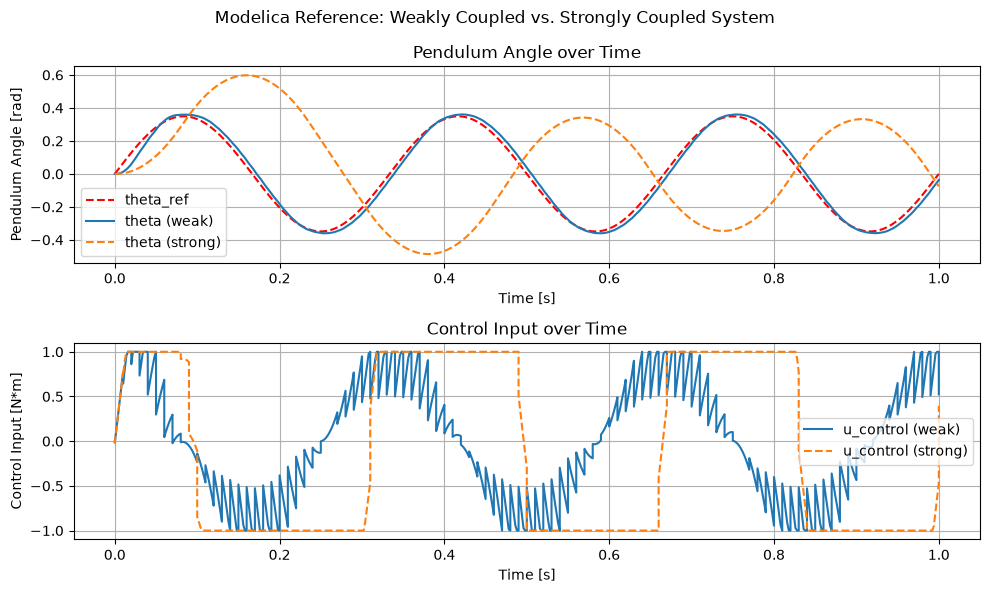

In [6]:
plt.figure(figsize=(10, 6),)
plt.suptitle("Modelica Reference: Weakly Coupled vs. Strongly Coupled System")
plt.subplot(2, 1, 1)
plt.plot(ref_strong_sol['time'], ref_strong_sol['set_point.theta_ref'], 'r--', label='theta_ref',)
plt.plot(ref_weak_sol['time'], ref_weak_sol['theta'], label='theta (weak)')
plt.plot(ref_strong_sol['time'], ref_strong_sol['theta'], label='theta (strong)', linestyle='dashed')
plt.xlabel('Time [s]')
plt.ylabel('Pendulum Angle [rad]')
plt.title('Pendulum Angle over Time')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(ref_weak_sol['time'], ref_weak_sol['u_control'], label='u_control (weak)')
plt.plot(ref_strong_sol['time'], ref_strong_sol['u_control'], label='u_control (strong)', linestyle='dashed')
plt.xlabel('Time [s]')
plt.ylabel('Control Input [N*m]')
plt.title('Control Input over Time')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Instantiate FMU Components

In [7]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

### Setpoint

In [8]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")
print_parameteres(setpoint)

Parameters of Setpoint:
  - amplitude: 0.3490658503988659 rad
  - frequency: 3.0 Hz
  - offset: 0.0 rad
  - phase: 0.0 rad


### PID Controller

In [9]:
pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDController"],
                   group="Controller")
print_parameteres(pid)

Parameters of PID:
  - Kd: 0.02
  - Ki: 8.0
  - Kp: 12.0
  - uMax: 1.0
  - uMin: -1.0


### Drive

In [10]:
drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveAdvanced"],
                     group="Actuator")

print_parameteres(drive)

Parameters of Drive:
  - I_max: 10.0 A
  - J_interface: 0.1 kg·m²
  - J_motor: 5.6×10⁻⁶ kg·m²
  - L_arm: 0.000121 H
  - R_arm: 0.151 Ohm
  - V_rated: 48.0 V
  - V_supply: 16.0 V
  - b_viscous: 0.01 m·N·s/rad
  - c: 100000.0 m·N/rad
  - d: 100.0 m·N·s/rad
  - eta: 0.85
  - gearRatio: 60.0
  - k_t: 0.03 m·N/A
  - n_0: 12916.0 1/min


### Pendulum

In [11]:
pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                        group="Plant")
print_parameteres(pendulum)

Parameters of Pendulum:
  - J: 0.04422682215965719 kg·m²
  - L: 0.18165085343803214 m
  - b_viscous: 0.0 m·N·s/rad
  - g: 9.81 m/s²
  - m: 1.0842960702239823 kg
  - omega_eps: 0.001 rad/s
  - omega_start: 0.0 rad/s
  - tau_c: 0.0 m·N
  - theta_start: 0.0 rad


### Angle Sesnsor and Decoder

In [12]:
angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")
print_parameteres(angle_sensor)

Parameters of Angle Sensor:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


In [13]:
angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")

print_parameteres(angle_decoder)

Parameters of Angle Decoder:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


## Define Connections

In [14]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c3 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c4 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["phi"].name,
)

c8 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

c9 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["alpha"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["alpha"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7, c8, c9]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]


## Build and Initialize the System

In [15]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

In [16]:
system = System(name="Strongly Coupled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

print(system.describe())


[ijcsa] DEBUG: Solving algebraic SCC ['Pendulum', 'Drive']:


[ijcsa] DEBUG: Interface inputs: [('Drive', 'alpha'), ('Drive', 'omega'), ('Drive', 'phi'), ('Pendulum', 'tau')]


[ijcsa] DEBUG: Internal zero-delay connections [('Drive', 'torque', 'Pendulum', 'tau'), ('Pendulum', 'theta', 'Drive', 'phi'), ('Pendulum', 'omega', 'Drive', 'omega'), ('Pendulum', 'alpha', 'Drive', 'alpha')]


[ijcsa] DEBUG: External zero-delay inputs []


[ijcsa] DEBUG: Initial guess for Drive.alpha = 0.0


...

[ijcsa] DEBUG: Committed solved input Drive.alpha = 0.0


[ijcsa] DEBUG: Committed solved input Drive.omega = 0.0


[ijcsa] DEBUG: Committed solved input Drive.phi = 0.0


[ijcsa] DEBUG: Committed solved input Pendulum.tau = 0.0


System 'Strongly Coupled Pendulum System'
  Algorithm: GaussSeidelAlgorithm
  Initialized: True
  Components (6):
    - Setpoint (FMUComponent): 0 in / 1 out
    - PID (FMUComponent): 2 in / 1 out [direct feedthrough]
    - Drive (FMUComponent): 4 in / 1 out [direct feedthrough]
    - Pendulum (FMUComponent): 1 in / 3 out [direct feedthrough]
    - Angle Decoder (FMUComponent): 1 in / 1 out [direct feedthrough]
    - Angle Sensor (FMUComponent): 1 in / 1 out [direct feedthrough]
  Connections (9):
    - Setpoint.theta_ref -> PID.theta_ref
    - Pendulum.theta -> Angle Sensor.theta
    - Angle Sensor.v_out -> Angle Decoder.v_in
    - Angle Decoder.theta -> PID.theta_meas
    - PID.u -> Drive.u_control
    - Drive.torque -> Pendulum.tau
    - Pendulum.theta -> Drive.phi
    - Pendulum.omega -> Drive.omega
    - Pendulum.alpha -> Drive.alpha
  Execution order:
    Generation 0: Drive, Pendulum, Setpoint
    Generation 1: Angle Sensor
    Generation 2: Angle Decoder
    Generation 3: PID
 

## Visualize the System Graph

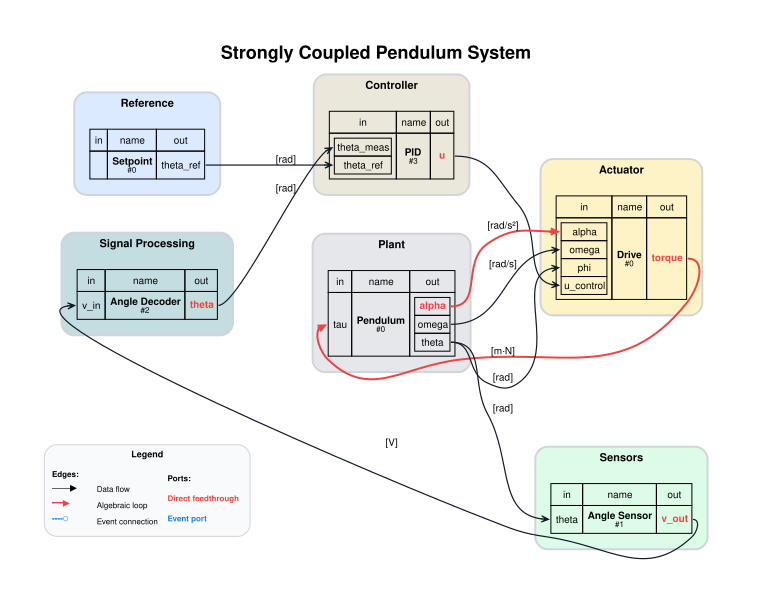

In [17]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [18]:
# Silence syssimx logging for the rest of the notebook
logging.getLogger("syssimx").setLevel(logging.WARNING)

## Baseline Run

In [19]:
t = 0.0
dt = 0.0005
t_end = 1.0

result = system.run(t, t_end, dt)

In [20]:
t_setpoint, setpoint_data = result["Setpoint"]
theta_ref = setpoint_data["theta_ref"]

t_pendulum, pendulum_data = result["Pendulum"]
theta_pendulum = pendulum_data["theta"]

t_decoder, decoder_data = result["Angle Decoder"]
theta_decoder = decoder_data["theta"]

t_pid, pid_data = result["PID"]
u_control = pid_data["u"]


## Plot: Baseline Trajectories with Strongly Coupled System

We can observe that the pendulum angle `theta` and the control input `u_control` from the syssimx simulation closely match the reference trajectories obtained from the Modelica simulation, indicating that our strongly coupled system is correctly capturing the dynamics of the original Modelica model.

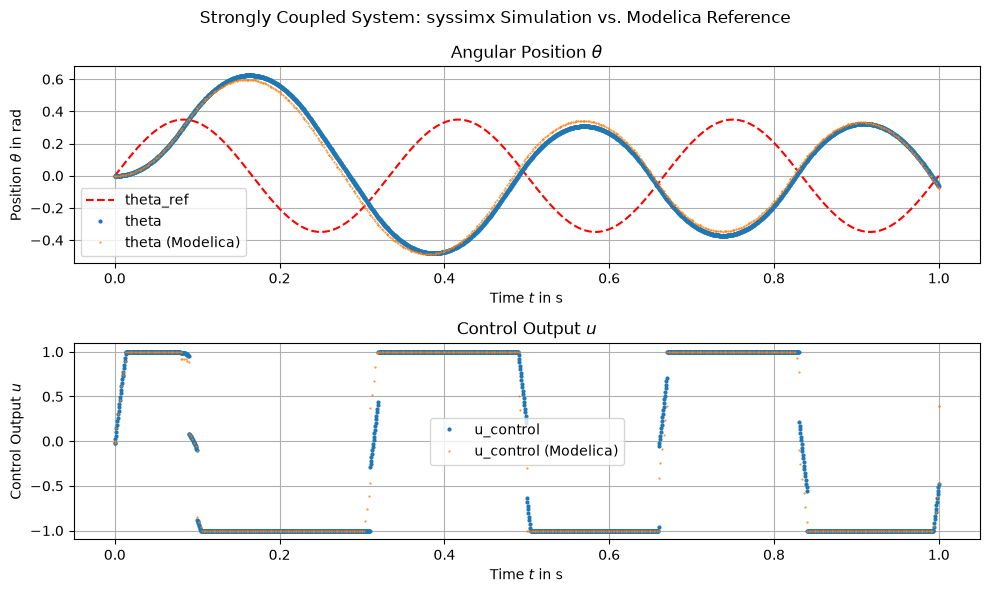

In [21]:
plt.figure(figsize=(10, 6),)
plt.suptitle("Strongly Coupled System: syssimx Simulation vs. Modelica Reference")
plt.subplot(2, 1, 1)
plt.plot(ref_strong_sol['time'], ref_strong_sol['set_point.theta_ref'], 'r--', label='theta_ref',)
plt.plot(t_pendulum, theta_pendulum, 'o', label='theta', markersize=2)
plt.plot(ref_strong_sol['time'], ref_strong_sol['theta'], '.', label='theta (Modelica)', markersize=1)
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Position $\theta$ in rad')
plt.title(r'Angular Position $\theta$')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_pid, u_control, 'o', label='u_control', markersize=2)
plt.plot(ref_strong_sol['time'], ref_strong_sol['u_control'], '.', label='u_control (Modelica)', markersize=1)
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Control Output $u$')
plt.title(r'Control Output $u$')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Experiment Design
We test three PID configurations and compare tracking and control effort.

### Helper: Run a PID Case

In [22]:
def run_pid_case(kp: float, ki: float, kd: float, dt: float = 0.001, t_end: float = 1.0):
    system.reset()
    pid.set_parameters(Kp=kp, Ki=ki, Kd=kd)

    system.initialize(t0=0.0)
    case_result = system.run(0.0, t_end, dt)

    t_ref, ref_data = case_result[setpoint.name]
    theta_ref = ref_data["theta_ref"]

    t_pend, pend_data = case_result[pendulum.name]
    theta = pend_data["theta"]

    t_drive, drive_data = case_result[drive.name]
    torque = drive_data["torque"]

    label = f"PID (Kp={kp}, Ki={ki}, Kd={kd})"

    return {
        "label": label,
        "t_ref": t_ref,
        "theta_ref": theta_ref,
        "t_theta": t_pend,
        "theta": theta,
        "t_torque": t_drive,
        "torque": torque,
        "kp": kp,
        "ki": ki,
        "kd": kd,
    }


## PID Parameter Study

In [23]:
cases = [
    run_pid_case(kp=8,  ki=8, kd=0.2),
    run_pid_case(kp=1,  ki=1, kd=0),
    run_pid_case(kp=10, ki=4, kd=0.15),
]

## Plot: Tracking Performance
Compare pendulum angle against the setpoint for each PID configuration.

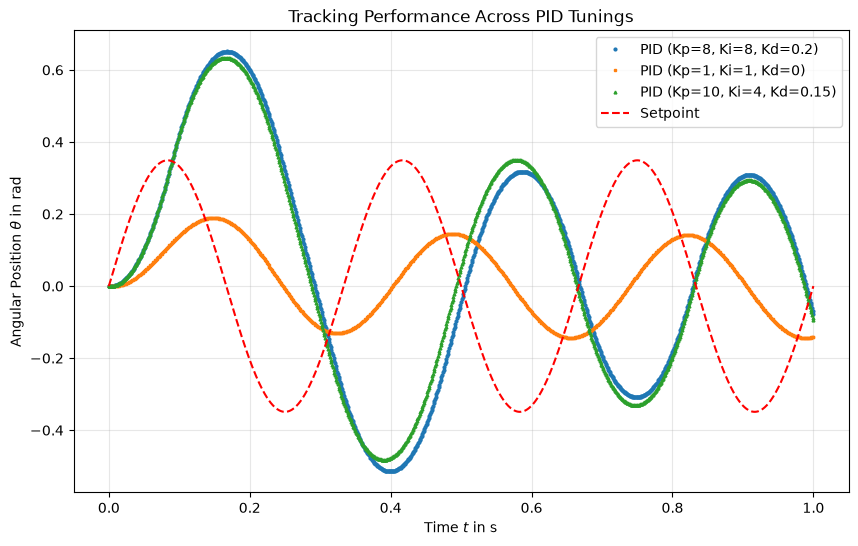

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(cases[0]['t_theta'], cases[0]['theta'], 'o', label=cases[0]['label'], markersize=2)
plt.plot(cases[1]['t_theta'], cases[1]['theta'], 's', label=cases[1]['label'], markersize=2)
plt.plot(cases[2]['t_theta'], cases[2]['theta'], '^', label=cases[2]['label'], markersize=2)


plt.plot(cases[0]['t_ref'], cases[0]['theta_ref'], label="Setpoint", color='red', linestyle="--", linewidth=1.5)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Angular Position $\theta$ in rad")
plt.title(r"Tracking Performance Across PID Tunings")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot: Drive Torque
Control effort for each PID configuration.

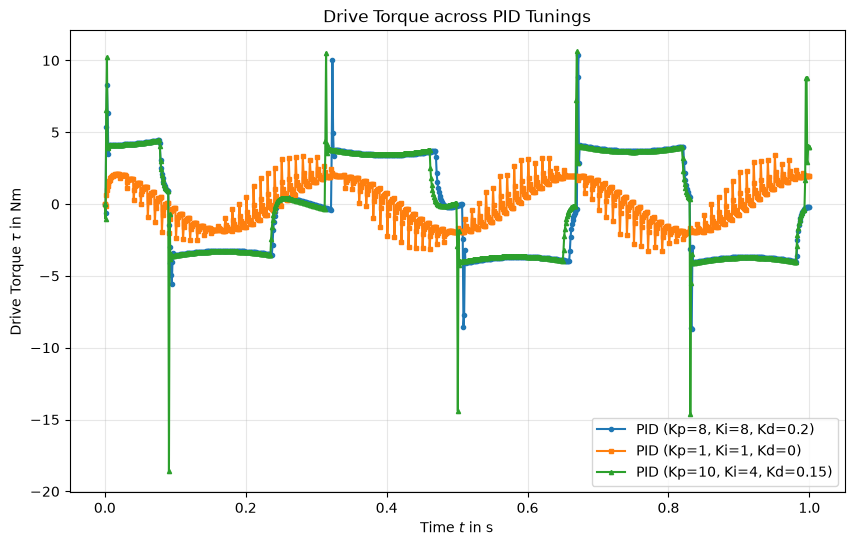

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(cases[0]['t_theta'], cases[0]['torque'], 'o-', label=cases[0]['label'], markersize=3)
plt.plot(cases[1]['t_theta'], cases[1]['torque'], 's-', label=cases[1]['label'], markersize=3)
plt.plot(cases[2]['t_theta'], cases[2]['torque'], '^-', label=cases[2]['label'], markersize=3)

plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Drive Torque $\tau$ in Nm")
plt.title(r"Drive Torque across PID Tunings")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary
- We need to adapt the PID parameters to achieve good tracking performance when the drive and pendulum are coupled through an algebraic loop.
- The "Medium" PID configuration shows significant oscillations and poor tracking, while the "Good" configuration achieves much better performance.
- The spikes in the drive torque for the "Medium" case indicate aggressive control actions that may lead to instability, while the "Good" case shows smoother control effort.